# 03 — Customer Segmentation (K-Means on RFM)
Segment customers by purchasing behavior using Recency, Frequency, and Monetary features.

In [19]:
%matplotlib inline

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

PROJECT_ROOT = Path.cwd().parent
PROCESSED = PROJECT_ROOT / "data" / "processed" / "online_retail_clean.csv"
FIGURES   = PROJECT_ROOT / "reports" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(PROCESSED, parse_dates=["InvoiceDate"])
print(f"Loaded {len(df):,} rows")

C:\Users\powell\AppData\Local\Temp\ipykernel_11188\3202520907.py:18: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(PROCESSED, parse_dates=["InvoiceDate"])


Loaded 530,104 rows


In [20]:
# Drop rows with missing CustomerID (required for per-customer aggregation)
df = df.dropna(subset=["CustomerID"]).copy()
df["CustomerID"] = df["CustomerID"].astype(str).str.replace(r"\.0$", "", regex=True)
print(f"Rows with CustomerID: {len(df):,}")
print(f"Unique customers: {df['CustomerID'].nunique():,}")

Rows with CustomerID: 397,884
Unique customers: 4,338


In [21]:
# Build RFM matrix
# Reference date = one day after the last invoice in the dataset
max_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)
print(f"Reference date: {max_date}")

rfm = (
    df.groupby("CustomerID")
    .agg(
        Recency=("InvoiceDate", lambda x: (max_date - x.max()).days),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("TotalPrice", "sum"),
    )
)

print(f"RFM matrix shape: {rfm.shape}")
print(rfm.describe().round(2))
rfm.head(10)

Reference date: 2011-12-10 12:50:00
RFM matrix shape: (4338, 3)
       Recency  Frequency   Monetary
count  4338.00    4338.00    4338.00
mean     92.54       4.27    2054.27
std     100.01       7.70    8989.23
min       1.00       1.00       3.75
25%      18.00       1.00     307.41
50%      51.00       2.00     674.48
75%     142.00       5.00    1661.74
max     374.00     209.00  280206.02


,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40
12352,36,8,2506.04
12353,204,1,89.00
12354,232,1,1079.40
12355,214,1,459.40


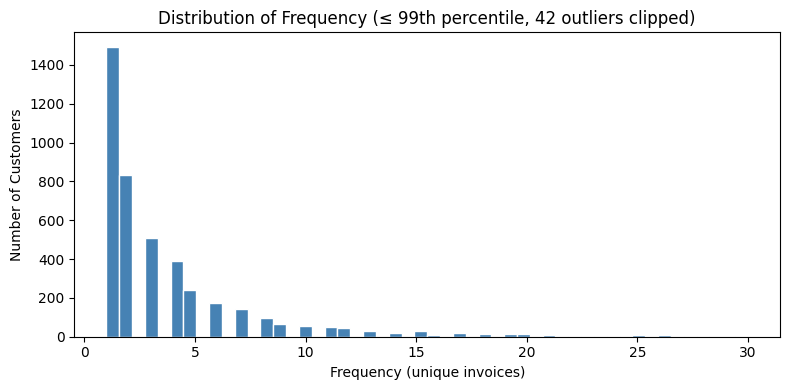

In [22]:
# Frequency distribution (clipped to 99th percentile for readability)
p99 = rfm["Frequency"].quantile(0.99)
clipped = rfm["Frequency"][rfm["Frequency"] <= p99]
n_outliers = len(rfm) - len(clipped)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(clipped, bins=50, color="steelblue", edgecolor="white")
ax.set_xlabel("Frequency (unique invoices)")
ax.set_ylabel("Number of Customers")
ax.set_title(f"Distribution of Frequency (≤ 99th percentile, {n_outliers} outliers clipped)")
plt.tight_layout()
fig.savefig(FIGURES / "rfm_frequency_dist.png", dpi=150)
plt.show()

In [23]:
# Log-transform RFM to reduce impact of extreme outliers, then scale
rfm_log = rfm[["Recency", "Frequency", "Monetary"]].apply(np.log1p)

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)
rfm_scaled = pd.DataFrame(rfm_scaled, columns=rfm_log.columns, index=rfm_log.index)

print("Log-transformed + scaled RFM stats:")
print(rfm_scaled.describe().round(2))

Log-transformed + scaled RFM stats:
       Recency  Frequency  Monetary
count  4338.00    4338.00   4338.00
mean     -0.00      -0.00      0.00
std       1.00       1.00      1.00
min      -2.34      -0.96     -4.00
25%      -0.66      -0.96     -0.69
50%       0.09      -0.36     -0.06
75%       0.84       0.65      0.65
max       1.56       5.86      4.73


In [24]:
# Elbow method and silhouette scores
K_RANGE = range(2, 11)
inertias = []
sil_scores = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(rfm_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(rfm_scaled, labels))
    print(f"k={k:2d}  inertia={km.inertia_:10.1f}  silhouette={sil_scores[-1]:.4f}")

k= 2  inertia=    6481.2  silhouette=0.4329
k= 3  inertia=    4867.7  silhouette=0.3365
k= 4  inertia=    3938.3  silhouette=0.3371
k= 5  inertia=    3296.0  silhouette=0.3160
k= 6  inertia=    2854.7  silhouette=0.3134
k= 7  inertia=    2549.0  silhouette=0.3099
k= 8  inertia=    2336.9  silhouette=0.3029
k= 9  inertia=    2155.5  silhouette=0.2813
k=10  inertia=    1999.8  silhouette=0.2786


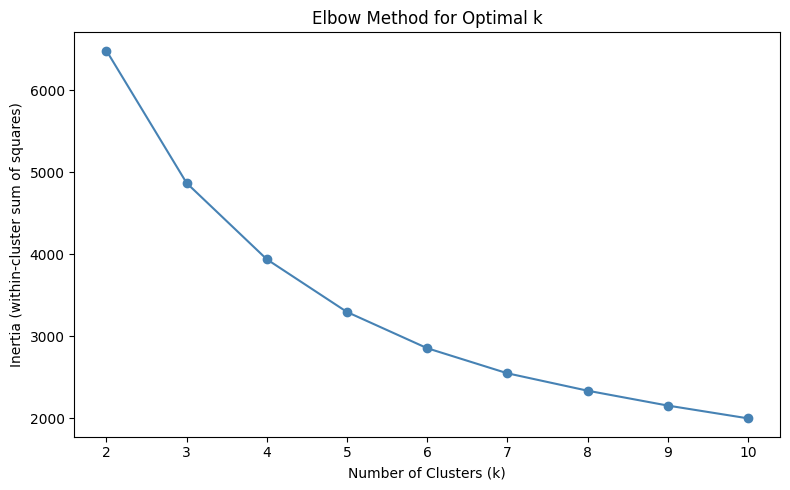

In [25]:
# Elbow plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(K_RANGE), inertias, marker="o", color="steelblue")
ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("Inertia (within-cluster sum of squares)")
ax.set_title("Elbow Method for Optimal k")
ax.set_xticks(list(K_RANGE))
plt.tight_layout()
fig.savefig(FIGURES / "kmeans_elbow.png", dpi=150)
plt.show()

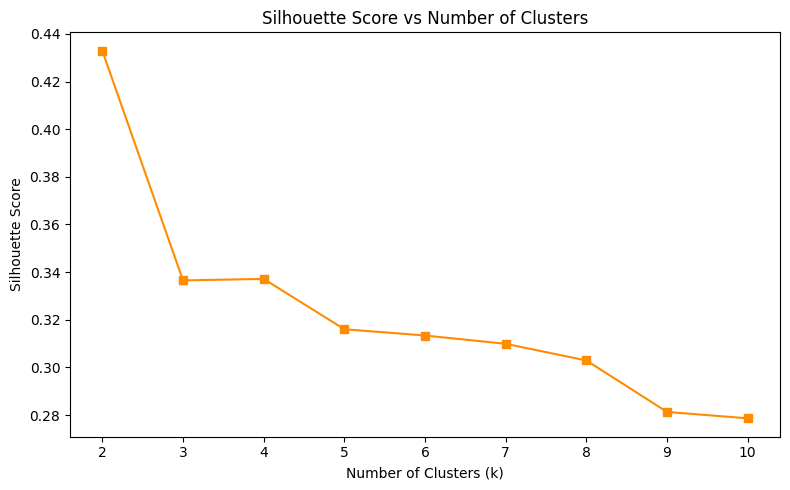

In [26]:
# Silhouette score plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(K_RANGE), sil_scores, marker="s", color="darkorange")
ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("Silhouette Score")
ax.set_title("Silhouette Score vs Number of Clusters")
ax.set_xticks(list(K_RANGE))
plt.tight_layout()
fig.savefig(FIGURES / "kmeans_silhouette.png", dpi=150)
plt.show()

## Choosing k

*Based on the elbow and silhouette plots above, select the best k. Update `BEST_K` in the next cell.*

In [27]:
# Final KMeans with chosen k
BEST_K = 2  # <-- adjust after reviewing elbow/silhouette

km_final = KMeans(n_clusters=BEST_K, n_init=10, random_state=42)
rfm["Cluster"] = km_final.fit_predict(rfm_scaled)

print("Cluster sizes:")
print(rfm["Cluster"].value_counts().sort_index())

Cluster sizes:
Cluster
0    2671
1    1667
Name: count, dtype: int64


         Recency  Frequency  Monetary
Cluster                              
0          134.1        1.7     497.7
1           25.9        8.4    4548.3


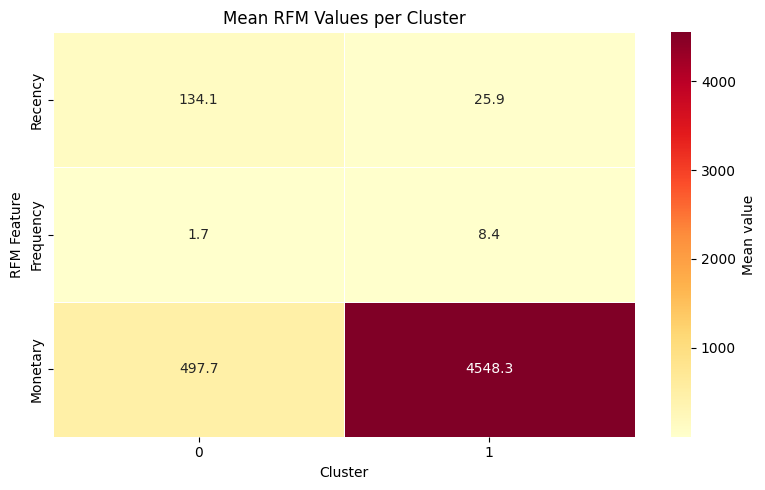

In [28]:
# Cluster summary: mean RFM per cluster
cluster_summary = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()
print(cluster_summary.round(1))

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    cluster_summary.T,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    ax=ax,
    linewidths=0.5,
    cbar_kws={"label": "Mean value"},
)
ax.set_title("Mean RFM Values per Cluster")
ax.set_xlabel("Cluster")
ax.set_ylabel("RFM Feature")
plt.tight_layout()
fig.savefig(FIGURES / "kmeans_rfm_heatmap.png", dpi=150)
plt.show()

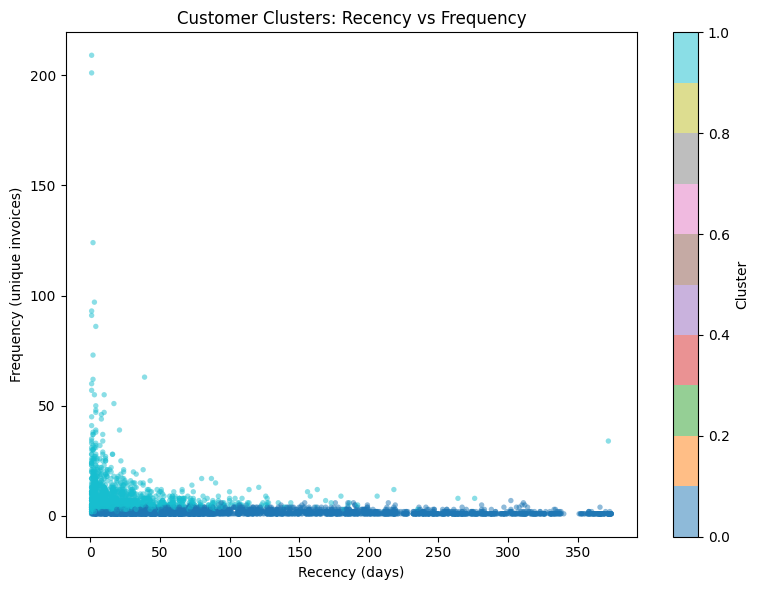

In [29]:
# Scatter: Recency vs Frequency
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    rfm["Recency"],
    rfm["Frequency"],
    c=rfm["Cluster"],
    cmap="tab10",
    alpha=0.5,
    s=15,
    edgecolors="none",
)
ax.set_xlabel("Recency (days)")
ax.set_ylabel("Frequency (unique invoices)")
ax.set_title("Customer Clusters: Recency vs Frequency")
plt.colorbar(scatter, ax=ax, label="Cluster")
plt.tight_layout()
fig.savefig(FIGURES / "kmeans_recency_frequency.png", dpi=150)
plt.show()

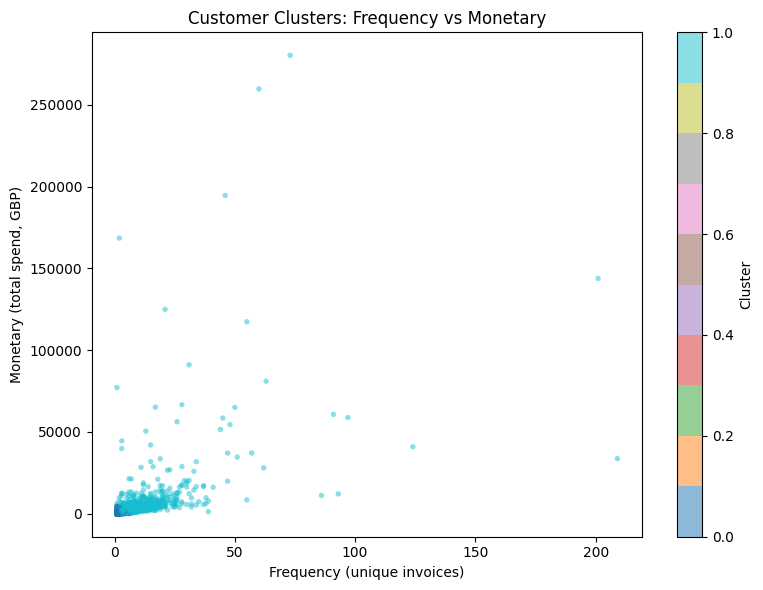

In [30]:
# Scatter: Frequency vs Monetary
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    rfm["Frequency"],
    rfm["Monetary"],
    c=rfm["Cluster"],
    cmap="tab10",
    alpha=0.5,
    s=15,
    edgecolors="none",
)
ax.set_xlabel("Frequency (unique invoices)")
ax.set_ylabel("Monetary (total spend, GBP)")
ax.set_title("Customer Clusters: Frequency vs Monetary")
plt.colorbar(scatter, ax=ax, label="Cluster")
plt.tight_layout()
fig.savefig(FIGURES / "kmeans_frequency_monetary.png", dpi=150)
plt.show()

In [ ]:
## Interpretation

*Write your interpretation here. Describe each cluster in business terms (e.g., Champions, Loyal, At Risk, Lost) based on their RFM profiles.*

## Interpretation and Segment Profiles

**Discovery Question:** *What is the distribution of spending across the customer base?*

### Key Findings

K-Means clustering on the RFM feature space identified 2 distinct customer segments, chosen based on the elbow and silhouette analysis.

### Cluster Profiles

There is one group of customers that encompasses the vast majority of the customer base. This group is concentrated on the left side of every distribution, and is fairly evenly right-skewed. The other group are the outliers, who do not form any distinct cluster. The fairly tight linear relationship between monetary value and frequency suggests that there is a strong correlation between the two, and there are essentially no significantly different customer segments, aside from whale outliers. This is apparently a fairly common occurrence in retail datasets.